## STA 314 Tut 8: Neural Networks

Goals:
* Learn how to fit and evaluate neural networks using PyTorch
* Compare the performance of neural networks with simpler regression models
* Compare convolutional neural networks with fully connected neural networks for image datape
* Explore the use of Neural Networks for sentiment analysis.

### 0. Install and Import Necessary Packages

In [ ]:
!pip install ISLP
!pip install torch
!pip install torchinfo
!pip install torchvision
!pip install pytorch_lightning

In [ ]:
import numpy as np , pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.linear_model import (LinearRegression, LogisticRegression, Lasso)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import (train_test_split, GridSearchCV)
import torch
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import TensorDataset
from torchmetrics import (MeanAbsoluteError, R2Score)
from torchinfo import summary
from torchvision.io import read_image
from torchvision.datasets import MNIST
from ISLP.torch.imdb import (load_lookup, load_tensor, load_sparse, load_sequential)
from ISLP.torch import (SimpleDataModule, SimpleModule, ErrorTracker, rec_num_workers)

from pytorch_lightning import seed_everything
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger
from torchvision.transforms import (Resize, Normalize, CenterCrop, ToTensor)

### 1. Neural Networks for Regression: Hitters Dataset

---



We will fit a Neural Network to the Hitters dataset to predict player salary and compare its predictive performance with linear models. We will examine the *mean absolute error* of each model on a test set.

$$MAE = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$$


Our goal here will be to predict ```Salary``` given the other features.

In [ ]:
Hitters = load_data('Hitters').dropna()
n = Hitters.shape[0]
Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [ ]:
model = MS(Hitters.columns.drop('Salary'), intercept=False)
# Convert X and Y to numpy arrays
X = model.fit_transform(Hitters).to_numpy()
Y = Hitters['Salary'].to_numpy()

# Split into train and test data
(X_train, X_test, Y_train, Y_test) = train_test_split(X, Y, test_size =1/3, random_state =1)

We first fit a linear regression model using ordinary least squares. The resulting validation MAE is 259.7153 we will use this as a baseline to compare with other models.

In [ ]:
# Fit and evaluate OLS Linear regression
hit_lm = LinearRegression().fit(X_train, Y_train)
Yhat_test = hit_lm.predict(X_test)
np.abs(Yhat_test - Y_test).mean()

np.float64(259.7152883314631)

Next we fit a linear model using LASSO. The optimal parameter $\lambda$ is selected by performing a grid search over many possible values and selecting the one that achieves the best performance in terms of MAE.

Recall that LASSO performs both shrinkage and variable selection, which can improve predictive performance when irrelevant features are present.

In [ ]:
scaler = StandardScaler(with_mean=True , with_std=True)
lasso = Lasso(warm_start=True , max_iter =30000)
standard_lasso = Pipeline(steps =[('scaler', scaler), ('lasso', lasso)])

X_s = scaler.fit_transform(X_train)
n = X_s.shape [0]
lam_max = np.fabs(X_s.T.dot(Y_train - Y_train.mean ())). max() / n
param_grid = {'alpha': np.exp(np.linspace (0, np.log (0.01) , 100))*lam_max}

cv = KFold (10, shuffle=True , random_state =1)
grid = GridSearchCV(lasso, param_grid, cv=cv, scoring='neg_mean_absolute_error')
grid.fit(X_train, Y_train);

The resulting validation MAE of our LASSO model is slightly lower than that of the unregularized OLS model.

In [ ]:
trained_lasso = grid.best_estimator_
Yhat_test = trained_lasso.predict(X_test)
np.fabs(Yhat_test - Y_test).mean()

np.float64(257.23820107995)

Finally, we construct and fit a simple neural network to the hitters dataset. We first define a class, ```Hitters Model```, that specifies the architecture of the model we'd like to fit.

In [ ]:
class HittersModel(nn.Module):
  def __init__(self , input_size):
    super(HittersModel , self).__init__ ()
    self.flatten = nn.Flatten ()
    self.sequential = nn.Sequential(
        nn.Linear(input_size , 50),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear (50, 1))
  def forward(self , x):
    x = self.flatten(x)
    return torch.flatten(self.sequential(x))

The ```hitters``` dataset has $19$ features. The first layer of our model performs a linear transformation from $\mathbb{R}^{19}$ to $\mathbb{R}^{50}$. This corresponds to a mapping of the form $$Ax + b,\quad A\in \mathbb{R}^{50\times 19}, ~b\in \mathbb{R}^{50}$$ which gives us $50*19 + 50 = 1000$ total trainable parameters for this layer.

The output is then passed through a ReLU activation function, followed by a dropout layer for regularization. Finally, a second linear transformation maps $\mathbb{R}^{50}$ to $\mathbb{R}^{1}$ to produce the predicted salary. The final linear mapping adds an additional $50*1 + 1 = 51$ training parameters for a total of $1051$ across the model.


We can quickly check the number of trainable parameters and get an overview of our model architecture by calling the summary function from the ```torchinfo``` package. This function shows us the shape of the input tensor as it passes through each layer of our network and displays the number of trainable parameters in each layer.

In [ ]:
seed_everything(1, workers=True)

hit_model = HittersModel(X.shape[1])

summary(hit_model,
  input_size=X_train.shape,
  col_names =['input_size', 'output_size', 'num_params'])

INFO:lightning_fabric.utilities.seed:Seed set to 1


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
HittersModel                             [175, 19]                 [175]                     --
├─Flatten: 1-1                           [175, 19]                 [175, 19]                 --
├─Sequential: 1-2                        [175, 19]                 [175, 1]                  --
│    └─Linear: 2-1                       [175, 19]                 [175, 50]                 1,000
│    └─ReLU: 2-2                         [175, 50]                 [175, 50]                 --
│    └─Dropout: 2-3                      [175, 50]                 [175, 50]                 --
│    └─Linear: 2-4                       [175, 50]                 [175, 1]                  51
Total params: 1,051
Trainable params: 1,051
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.18
Input size (MB): 0.01
Forward/backward pass size (MB): 0.07
Params size (MB): 0.00
Estimated Total Size (MB): 0.09

Before training, we convert the data from NumPy arrays to torch tensors. We then wrap the data in a DataLoader, which allows us to easily iterate over batches during training.


In [ ]:
seed_everything(1, workers=True)


# Convert train and test set into format compatible with pytorch
X_train_t = torch.tensor(X_train.astype(np.float32))
Y_train_t = torch.tensor(Y_train.astype(np.float32))
hit_train = TensorDataset(X_train_t , Y_train_t)

X_test_t = torch.tensor(X_test.astype(np.float32))
Y_test_t = torch.tensor(Y_test.astype(np.float32))
hit_test = TensorDataset(X_test_t , Y_test_t)

# Set up data loader for training/testing and specify batch size
hit_dm = SimpleDataModule(hit_train, hit_test, batch_size =32, validation=hit_test)

# Specify that we want the validation MAE to be logged throughout training
hit_module = SimpleModule.regression(hit_model, metrics ={'mae':MeanAbsoluteError()})
hit_logger = CSVLogger('logs ', name='hitters ')

INFO:lightning_fabric.utilities.seed:Seed set to 1


We can now train the model. At each step SGD is performed with a batch size of 32. The Trainer automates the training loop for us, incleading the forward passes, backpropagation, and validation. We only need to specify the number of epochs and how often we'd like to log the validation error.
Specifying ```max_epochs = 50``` ensures that we loop through the entire training set at most 50 times.


In [ ]:
seed_everything(1, workers=True)
hit_trainer = Trainer(deterministic=True, max_epochs =50, log_every_n_steps = 5, logger=hit_logger, callbacks =[ ErrorTracker ()])
hit_trainer.fit(hit_module , datamodule=hit_dm)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ HittersModel │  1.1 K │ train │     0 │
│ 1 │ loss  │ MSELoss      │      0 │ train │     0 │
└───┴───────┴──────────────┴────────┴───────┴───────┘

Trainable params: 1.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


We can then investigate how the training and validation MAE changed over the Epochs of training.

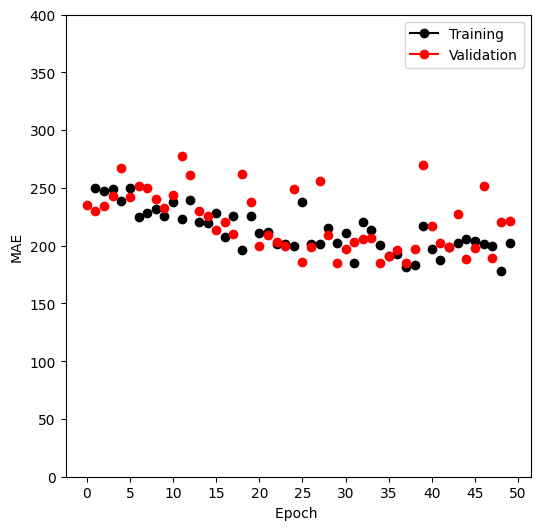

In [ ]:
def summary_plot(results, ax, col='loss', valid_legend='Validation', training_legend='Training', ylabel='Loss', fontsize =20):
  for (column, color, label) in zip([f'train_{col}_epoch', f'valid_{col}'], ['black', 'red'], [training_legend , valid_legend ]):
    results.plot(x='epoch', y=column, label=label, marker='o', color=color, ax=ax)
    ax.set_xlabel('Epoch ')
    ax.set_ylabel(ylabel)
  return ax

hit_results = pd.read_csv(hit_logger.experiment.metrics_file_path)
fig , ax = subplots(1, 1, figsize =(6, 6))
ax = summary_plot(hit_results, ax, col='mae', ylabel='MAE', valid_legend='Validation')
ax.set_ylim ([0, 400])
ax.set_xticks(np.linspace (0, 50, 11).astype(int));

Now we evaluate the model on the test set. The neural network achieves substantially lower MAE on the test set than both the linear models, suggesting they were not flexible enough to capture the data.

In [ ]:
hit_model.eval()
preds = hit_module(X_test_t)
torch.abs(Y_test_t - preds).mean()

tensor(221.7649, grad_fn=<MeanBackward0>)

### 2. Convolution Neural Networks: MNIST Dataset

For the second part of this lab we will turn our attention towards the MNIST dataset. MNIST contains 60000 observations of handwritten digits along with the corresponding labels. Each observation is stored as a $28\times 28$ matrix of pixels. The goal is to correctly identify the digit that has been drawn given a $28\times 28$ pixel image as input.

In [ ]:
(mnist_train, mnist_test) = [MNIST(root='data ', train=train , download=True, transform=ToTensor ()) for train in [True , False ]]
mnist_train

100%|██████████| 9.91M/9.91M [00:00<00:00, 64.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.76MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 12.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.66MB/s]


Dataset MNIST
    Number of datapoints: 60000
    Root location: data 
    Split: Train
    StandardTransform
Transform: ToTensor()

We construct a data loader with a batch size of 256 and specify that we'd like to use 20\% of our training data for validation.

In [ ]:
# Construct data loader from the MNIST data
mnist_dm = SimpleDataModule(mnist_train, mnist_test, validation =0.2, batch_size =256)

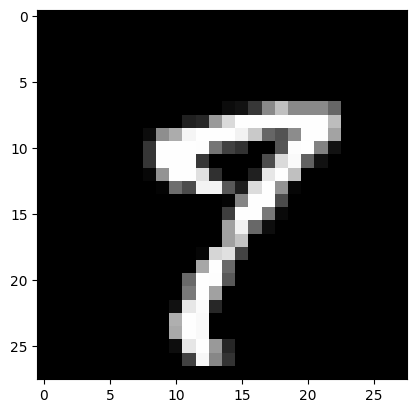

Label: 7


In [ ]:
# Rerun for different images
for idx , (X_ ,Y_) in enumerate(mnist_dm.train_dataloader ()):
  break

plt.imshow(X_[0][0], cmap="gray")
plt.show()
print("Label:", Y_[0].item())

For our first approach, we'll vectorize the image immediately and not take advantage of any potential spatial structure.

We define a network with two hidden layers. The first takes as input the $28\times 28$ matrix of pixels and flattens it into a vector of length $784$, which is passed through a linear layer mapping $784$ to $256$, followed by ReLU activation and dropout.


The second hidden layer maps $256$ to $128$ followed by ReLU and dropout. The output layer applies a final linear transformation from $128$ dimensions to $10$ producing a vector of class scores where each entry corresponds to a digit.


In [ ]:
class MNISTModel(nn.Module):
  def __init__(self):
    super(MNISTModel , self).__init__ ()

    self.layer1 = nn.Sequential(
        nn.Flatten (), # Flattens the 28 by 28 image into a vector of length 28*28
        nn.Linear (28*28 , 256),
        nn.ReLU(),
        nn.Dropout (0.4))

    self.layer2 = nn.Sequential(
        nn.Linear (256, 128),
        nn.ReLU(),
        nn.Dropout (0.3))

    self._forward = nn.Sequential(
        self.layer1 ,
        self.layer2 ,
        nn.Linear (128, 10))

  def forward(self , x):
    return self._forward(x)

In [ ]:
seed_everything(1, workers=True)

mnist_model = MNISTModel()
mnist_model(X_).size()

INFO:lightning_fabric.utilities.seed:Seed set to 1


torch.Size([256, 10])

We use the summary function to examine the shape of our network and the number of trainable parameters as we did in the previous section. The model we fit previously had roughly 1000 parameters but this one has over 200,000!

In [ ]:
summary(mnist_model, input_data=X_, col_names =['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MNISTModel                               [256, 1, 28, 28]          [256, 10]                 --
├─Sequential: 1-1                        [256, 1, 28, 28]          [256, 10]                 --
│    └─Sequential: 2-1                   [256, 1, 28, 28]          [256, 256]                --
│    │    └─Flatten: 3-1                 [256, 1, 28, 28]          [256, 784]                --
│    │    └─Linear: 3-2                  [256, 784]                [256, 256]                200,960
│    │    └─ReLU: 3-3                    [256, 256]                [256, 256]                --
│    │    └─Dropout: 3-4                 [256, 256]                [256, 256]                --
│    └─Sequential: 2-2                   [256, 256]                [256, 128]                --
│    │    └─Linear: 3-5                  [256, 256]                [256, 128]                32,896
│    │    └─ReLU: 3-6     

In [ ]:
mnist_module = SimpleModule.classification(mnist_model, num_classes=10)
mnist_logger = CSVLogger('logs', name='MNIST')

We are now ready to train the model. The number of Epochs is set fairly low by default to ensure reasonable training time. Feel free to adjust this on your machine and investigate how performance changes.

In [ ]:
seed_everything(1, workers=True)

# Number of Epochs can be increased but takes a while to run
mnist_trainer = Trainer(deterministic=True, max_epochs =1, logger=mnist_logger, callbacks =[ ErrorTracker ()])
mnist_trainer.fit(mnist_module, datamodule=mnist_dm)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MNISTModel       │  235 K │ train │     0 │
│ 1 │ loss  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 235 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 235 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


We defined a fairly simple model that doesn't directly take advantage of the spatial structure of the image data in any way but it still achieves fairly good test accuracy.

In [ ]:
# Check model performance on the test set.
mnist_trainer.test(mnist_module, datamodule=mnist_dm)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9204999804496765     │
│         test_loss         │    0.27439719438552856    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.27439719438552856, 'test_accuracy': 0.9204999804496765}]

Lets see if we can improve the performance by using a Convolution Neural Network. Remember that this type of model is able to extract high-level spatial features from the image before then flatenning these extracted features and feeding them through the rest of the network for classification.


The ```BuildingBlock``` class we define below contains the general blueprint for our convolution blocks which allows us to easily add multiple blocks to our network.

In [ ]:
class BuildingBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super(BuildingBlock , self).__init__ ()
    self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                          kernel_size =(3 ,3), padding='same')
    self.activation = nn.ReLU()
    self.pool = nn.MaxPool2d(kernel_size =(2 ,2))
  def forward(self , x):
    return self.pool(self.activation(self.conv(x)))

class MNISTCNNModel(nn.Module):
  def __init__(self):
    super(MNISTCNNModel , self).__init__()
    sizes = [(1 ,16), (16 ,32)]
    self.conv = nn.Sequential (*[ BuildingBlock(in_ , out_) for in_ , out_ in sizes ])

    self.output = nn.Sequential(nn.Dropout (0.5),
                                nn.Linear (32 * 7 * 7 , 128),
                                nn.ReLU (),
                                nn.Linear (128, 10))
  def forward(self , x):
    val = self.conv(x)
    val = torch.flatten(val , start_dim =1)
    return self.output(val)

Calling the summary function again we can see that this model also has roughly 200,000 trainable parameters.

In [ ]:
seed_everything(1, workers=True)

mnistcnn_model = MNISTCNNModel()
summary(mnistcnn_model, input_data=X_, col_names =['input_size', 'output_size', 'num_params'])

INFO:lightning_fabric.utilities.seed:Seed set to 1


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MNISTCNNModel                            [256, 1, 28, 28]          [256, 10]                 --
├─Sequential: 1-1                        [256, 1, 28, 28]          [256, 32, 7, 7]           --
│    └─BuildingBlock: 2-1                [256, 1, 28, 28]          [256, 16, 14, 14]         --
│    │    └─Conv2d: 3-1                  [256, 1, 28, 28]          [256, 16, 28, 28]         160
│    │    └─ReLU: 3-2                    [256, 16, 28, 28]         [256, 16, 28, 28]         --
│    │    └─MaxPool2d: 3-3               [256, 16, 28, 28]         [256, 16, 14, 14]         --
│    └─BuildingBlock: 2-2                [256, 16, 14, 14]         [256, 32, 7, 7]           --
│    │    └─Conv2d: 3-4                  [256, 16, 14, 14]         [256, 32, 14, 14]         4,640
│    │    └─ReLU: 3-5                    [256, 32, 14, 14]         [256, 32, 14, 14]         --
│    │    └─MaxPool2d: 3-6     

In [ ]:
mnistcnn_optimizer = RMSprop(mnistcnn_model.parameters (), lr =0.001)
mnistcnn_module = SimpleModule.classification(mnistcnn_model, optimizer=mnistcnn_optimizer, num_classes=10)
mnistcnn_logger = CSVLogger('logs', name='MNISTCNN')

In [ ]:
seed_everything(1, workers=True)

# max_epochs can be increased but will take a while to run
mnistcnn_trainer = Trainer(deterministic=True, max_epochs =1, logger=mnistcnn_logger , callbacks =[ErrorTracker()])
mnistcnn_trainer.fit(mnistcnn_module, datamodule=mnist_dm)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MNISTCNNModel    │  206 K │ train │     0 │
│ 1 │ loss  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 206 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 206 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


Even though the model has roughly the same number of parameters the test accuracy has noticeably improved!

In [ ]:
mnistcnn_trainer.test(mnistcnn_module, datamodule=mnist_dm)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9660999774932861     │
│         test_loss         │    0.11256636679172516    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.11256636679172516, 'test_accuracy': 0.9660999774932861}]

We can check the two models predictions for different images in the dataset.

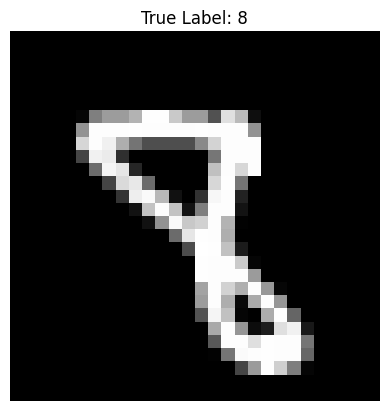

MNIST Model Prediction: 9
CNN MNIST Model Prediction: 8


In [ ]:
# Change the index to examine different images
single_image = X_[102]
single_label = Y_[102]


# Get prediction of simple mnist and cnn mnist model on single image
mnist_model.eval()
with torch.no_grad():
  mnist_output = mnist_model(single_image.unsqueeze(0))
  mnist_prediction = torch.argmax(mnist_output).item()

mnistcnn_model.eval()
with torch.no_grad():
  mnistcnn_output = mnistcnn_model(single_image.unsqueeze(0))
  mnistcnn_prediction = torch.argmax(mnistcnn_output).item()

plt.imshow(single_image.squeeze(0), cmap='gray')
plt.title(f"True Label: {single_label.item()}")
plt.axis('off')
plt.show()

print(f"MNIST Model Prediction: {mnist_prediction}")
print(f"CNN MNIST Model Prediction: {mnistcnn_prediction}")

### 3. Sentiment Analysis: IMDB Dataset

The final example we'll look at this lab is performing sentiment analysis on a dataset of IMDB reviews. The goal is to classify each review as "positive" or "negative". In the dataset the reviews are stored as numerical vectors where each number corresponds to the presence of a particular word in the review.

In other words, if we have a list of the 10000 most commonly used words in IMDB reviews, We can represent each of these words by a unique number from $1$ to $10000$. For example if the word "good" corresponds to the number $35$ and the word "casting" corresponds to the number "87" we could encode the review "good casting" as something like the sequence $(35, 87)$. To ensure that all vectorized reviews are of the same length we pad shorter vectors with zeros to ensure they are all of the same length.

In [ ]:
(imdb_seq_train, imdb_seq_test) = load_sequential(root='data/IMDB ')
padded_sample = np.asarray(imdb_seq_train.tensors [0][0])
sample_review = padded_sample[padded_sample > 0]
sample_review #without padding

array([   1,   14,   22,   16,   43,  530,  973, 1622, 1385,   65,  458,
       4468,   66, 3941,    4,  173,   36,  256,    5,   25,  100,   43,
        838,  112,   50,  670,    2,    9,   35,  480,  284,    5,  150,
          4,  172,  112,  167,    2,  336,  385,   39,    4,  172, 4536,
       1111,   17,  546,   38,   13,  447,    4,  192,   50,   16,    6,
        147, 2025,   19,   14,   22,    4, 1920, 4613,  469,    4,   22,
         71,   87,   12,   16,   43,  530,   38,   76,   15,   13, 1247,
          4,   22,   17,  515,   17,   12,   16,  626,   18,    2,    5,
         62,  386,   12,    8,  316,    8,  106,    5,    4, 2223, 5244,
         16,  480,   66, 3785,   33,    4,  130,   12,   16,   38,  619,
          5,   25,  124,   51,   36,  135,   48,   25, 1415,   33,    6,
         22,   12,  215,   28,   77,   52,    5,   14,  407,   16,   82,
          2,    8,    4,  107,  117, 5952,   15,  256,    4,    2,    7,
       3766,    5,  723,   36,   71,   43,  530,  4

In [ ]:
# Outputs an unvectorized review
lookup = load_lookup(root='data/IMDB ')
' '.join(lookup[i] for i in sample_review)

"<START> this film was just brilliant casting location scenery story direction everyone's really suited <UNUSED> part they played and you could just imagine being there robert <UNK> is an amazing actor and now <UNUSED> same being director <UNK> father came from <UNUSED> same scottish island as myself so i loved <UNUSED> fact there was a real connection with this film <UNUSED> witty remarks throughout <UNUSED> film were great it was just brilliant so much that i bought <UNUSED> film as soon as it was released for <UNK> and would recommend it to everyone to watch and <UNUSED> fly fishing was amazing really cried at <UNUSED> end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to <UNUSED> two little boy's that played <UNUSED> <UNK> of norman and paul they were just brilliant children are often left out of <UNUSED> <UNK> list i think because <UNUSED> stars that play them all grown up are such a big profile for <UNUSED> 

We begin by constructing a data loader and specfying the batch and validation size. In the previous example we gave a propotion of training data to use as validation but we can also explicitly state the number of samples we'd like to use.

In [ ]:
(imdb_train, imdb_test) = load_tensor(root='data/IMDB ')
imdb_dm = SimpleDataModule(imdb_train, imdb_test, validation =2000,batch_size =512)

We are now ready to choose our model architecture and use the summary function to check the total number of parameters. Even though the selected dimension for the hidden layer mappings is only 16 we still have a fair number of parameters because the input is quite high dimensional.

In [ ]:
class IMDBModel(nn.Module):
  def __init__(self , input_size):
    super(IMDBModel , self).__init__ ()
    self.dense1 = nn.Linear(input_size , 16)
    self.activation = nn.ReLU()
    self.dense2 = nn.Linear (16, 16)
    self.output = nn.Linear (16, 1)
  def forward(self , x):
    val = x
    for _map in [self.dense1, self.activation, self.dense2, self.activation,
                 self.output]:
      val = _map(val)
    return torch.flatten(val)

In [ ]:
seed_everything(1, workers=True)

imdb_model = IMDBModel(imdb_test.tensors [0]. size()[1])
summary(imdb_model, input_size=imdb_test.tensors [0]. size(),
        col_names =['input_size',
                    'output_size',
                    'num_params'])

INFO:lightning_fabric.utilities.seed:Seed set to 1


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
IMDBModel                                [25000, 10003]            [25000]                   --
├─Linear: 1-1                            [25000, 10003]            [25000, 16]               160,064
├─ReLU: 1-2                              [25000, 16]               [25000, 16]               --
├─Linear: 1-3                            [25000, 16]               [25000, 16]               272
├─ReLU: 1-4                              [25000, 16]               [25000, 16]               --
├─Linear: 1-5                            [25000, 16]               [25000, 1]                17
Total params: 160,353
Trainable params: 160,353
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 4.01
Input size (MB): 1000.30
Forward/backward pass size (MB): 6.60
Params size (MB): 0.64
Estimated Total Size (MB): 1007.54

In [ ]:
imdb_optimizer = RMSprop(imdb_model.parameters (), lr =0.001)
imdb_module = SimpleModule.binary_classification(imdb_model, optimizer=imdb_optimizer)

imdb_logger = CSVLogger('logs', name='IMDB')
imdb_trainer = Trainer(deterministic=True, max_epochs =5, logger=imdb_logger,
                       callbacks =[ ErrorTracker()])

imdb_trainer.fit(imdb_module, datamodule=imdb_dm)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ IMDBModel         │  160 K │ train │     0 │
│ 1 │ loss  │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 160 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 160 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches 
(45) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


After training we achieve a test accuracy of roughly $88\%$.

In [ ]:
test_results = imdb_trainer.test(imdb_module, datamodule=imdb_dm)
test_results

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8813199996948242     │
│         test_loss         │    0.30577611923217773    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.30577611923217773, 'test_accuracy': 0.8813199996948242}]

### 4. Exercise

With the remaining time until the quiz play around with the model architecture for the different examples and examine the impact on performance. Some things you can try:



*   Increase model complexity in the Hitters section. Does it make a difference if we add additional layers vs increase the number of parameters in existing layers?
*   Try increasing the number of training Epochs or changing the batch size.
*   Remove Dropout or change the proportion of connections dropped.

